# MDanalysis

This page walks through a full analysis of a molecular dynamics
trajectory with [MDAnalysis](https://www.mdanalysis.org), using
Molecular Nodes for the pictures along the way and a rendered animation
at the end. It follows the same workflow as the MDAnalysis User Guide
examples for
[RMSD](https://userguide.mdanalysis.org/stable/examples/analysis/alignment_and_rms/rmsd.html)
and
[RMSF](https://userguide.mdanalysis.org/stable/examples/analysis/alignment_and_rms/rmsf.html)
and [native
contacts](https://userguide.mdanalysis.org/stable/examples/analysis/distances_and_contacts/contacts_native_fraction.html)
and the domain-angle analysis from the classic [MDAnalysis
tutorial](https://github.com/MDAnalysis/MDAnalysisTutorial). Those
examples visualise their results with the browser-based
[nglview](https://github.com/nglviewer/nglview); here every render is
produced by Blender through the Molecular Nodes Python API instead, so
the same code that makes a quick preview in a notebook also makes a
publication figure or a movie.

The system is adenylate kinase (AdK), a 214-residue enzyme with three
domains that open and close around the active site: the rigid **CORE**,
the **NMP** binding domain (residues 30-59) and the **LID** domain
(residues 122-159). The [AdK equilibrium
dataset](https://www.mdanalysis.org/MDAnalysisData/adk_equilibrium.html)
from `MDAnalysisData` is a 1 µs simulation of the apo protein, saved
every 240 ps (4187 frames) with the solvent stripped, so it is small
enough (161 MB) to download during a workshop.

<figure>
<video src="attachment:adk.mp4" controls=""><a
href="attachment:adk.mp4">Final video produced at the end of this
tutorial.</a></video>
<figcaption aria-hidden="true">Final video produced at the end of this
tutorial.</figcaption>
</figure>

## Setup

### Python requirements

Molecular Nodes runs on the `bpy` module, which is Blender as a regular
Python package. Blender pins the Python version tightly, so the
environment must be **Python 3.13**. The easiest way to get a working
environment is with [`uv`](https://docs.astral.sh/uv/), which creates
and manages the virtual environment for you:

``` bash
uv init adk-workshop --python 3.13
cd adk-workshop
uv add "molecularnodes[bpy,jupyter]" MDAnalysisData matplotlib pandas
```

Or with `pip` inside an existing Python 3.13 environment:

``` bash
pip install "molecularnodes[bpy,jupyter]" MDAnalysisData matplotlib pandas
```

- `molecularnodes[bpy]` installs Blender itself (`bpy`, around 300 MB)
  alongside Molecular Nodes and its dependencies, which already include
  MDAnalysis.
- `[jupyter]` adds Jupyter and Pillow, so rendered images and videos
  display inline in a notebook. Molecular Nodes works from a plain
  script too, in which case pass `path=` to the render calls to save
  files instead.
- `MDAnalysisData` provides the example datasets. The first call to a
  `fetch_*` function downloads the data into `~/MDAnalysis_data/` and
  later calls reuse the cached copy.

Start a notebook with `uv run jupyter lab` (or `jupyter lab` in the
activated environment) and check that everything imports:

In [1]:
import molecularnodes as mn
from molecularnodes.nodes import geometry as mg
from nodebpy import geometry as g
from nodebpy import shader as s
import MDAnalysis as mda
from MDAnalysis.analysis import align, rms
from MDAnalysisData import datasets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(f"MDAnalysis {mda.__version__}")

MDAnalysis 2.10.0

> **Rendering without a GPU**
>
> Everything on this page renders on the CPU. If your machine has no GPU
> (a laptop, a cloud notebook or a cluster node), also switch the
> compositor to the CPU right after creating the canvas:
> `canvas.compositor.device = "CPU"`. Blender defaults it to the GPU and
> aborts the render on a machine without one.

### Create the canvas

The [`Canvas`](../api/reference/Canvas.html#molecularnodes.Canvas) is
the handle on the Blender scene: render engine, resolution, camera and
lighting all live here. Create it before loading any structures. Still
images use
[Cycles](https://docs.blender.org/manual/en/latest/render/cycles/index.html)
with a modest sample count, which takes around ten seconds per frame on
a laptop CPU.

In [2]:
canvas = mn.Canvas(mn.scene.Cycles(samples=32), resolution=(1280, 720))
canvas.background = (0.02, 0.02, 0.03, 1.0)

00:00.487  cycles           | WARNING HIPEW initialization failed: Error opening HIP dynamic library

## Load the trajectory

`MDAnalysisData` returns a bunch with the paths to the topology and
trajectory files, plus a `DESCR` string describing the simulation.
Everything else is standard MDAnalysis: a
[`Universe`](https://docs.mdanalysis.org/stable/documentation_pages/core/universe.html#MDAnalysis.core.universe.Universe)
that we will analyse and render.

In [3]:
adk = datasets.fetch_adk_equilibrium()
u = mda.Universe(adk.topology, adk.trajectory)

print(u)
print(f"{u.trajectory.n_frames} frames, {u.trajectory.dt:.0f} ps apart, "
      f"{u.trajectory.totaltime / 1e6:.2f} µs in total")

<Universe with 3341 atoms>
4187 frames, 240 ps apart, 1.00 µs in total

The three domains are defined by residue ranges. We keep the MDAnalysis
selection strings in one dictionary, and a colour for each, so the
analysis and the renders always agree on what a domain is.

In [4]:
DOMAINS = {
    "CORE": "resid 1:29 or resid 60:121 or resid 160:214",
    "NMP": "resid 30:59",
    "LID": "resid 122:159",
}
DOMAIN_COLORS = {
    "CORE": (0.75, 0.75, 0.78, 1.0),
    "NMP": (0.95, 0.50, 0.12, 1.0),
    "LID": (0.15, 0.55, 0.95, 1.0),
}

## First look at the protein

A [`Molecule`](../api/reference/Molecule.html#molecularnodes.Molecule)
wraps the `Universe` and creates the object in the Blender scene. It
stays linked to the `Universe`: changing the scene frame steps the
trajectory, and transformations applied in MDAnalysis show up in the
render.

In [5]:
traj = mn.Molecule(u)

### A custom material

Rather than one of the pre-built materials, we build one from scratch
with `nodebpy`’s shader nodes. The `MNColor` node reads the per-atom
colours that the geometry nodes produce, some ambient occlusion darkens
the crevices, and a coat on the Principled BSDF gives the cartoon a
glossy finish. `fake_user=True` keeps the material alive when the scene
is cleared later on, so the animation at the end can reuse it.

In [6]:
with s.material("Glossy Domains", fake_user=True) as glossy:
    glossy.nodes.clear()
    color = mn.nodes.shader.MNColor()
    ao = s.AmbientOcclusion(color, distance=0.4, samples=32)
    bsdf = s.PrincipledBSDF(base_color=ao.o.color, roughness=0.3, coat_weight=0.5)
    bsdf >> s.MaterialOutput().i.surface

### Styling with the node tree

[`add_style`](../api/reference/Molecule.html#molecularnodes.Molecule.add_style)
covers the common cases, but for anything with several steps we build
the geometry node tree directly with `mol.tree`. Inside the `with`
block, `>>` links one node into the next, `atoms` is the raw atomic data
coming in and `join` collects everything that should be rendered.

Each domain gets a `Set Color` node whose `selection` is an MDAnalysis
selection string turned into a node with
[`node`](../api/reference/entities.molecule.SelectionManager.html#molecularnodes.entities.molecule.SelectionManager.node).
The PSF topology carries no secondary structure, so a `Topology DSSP`
node computes it per frame before the cartoon is built.

In [7]:
def color_domains(mol, atoms):
    """Chain one Set Color node per domain onto `atoms` and return the result."""
    for name, selection in DOMAINS.items():
        atoms = atoms >> mg.SetColor(
            selection=mol.selections.node(selection),
            color=DOMAIN_COLORS[name],
        )
    return atoms


with traj.tree.reset() as (atoms, join):
    (
        color_domains(traj, atoms)
        >> mg.TopologyDSSP()
        >> mg.StyleCartoon(quality=4, material=glossy.material)
        >> join
    )

canvas.look_at(traj, viewpoint="top", margin=0.15)
canvas.snapshot()

> **Note**
>
> The order of the nodes matters: anything placed *between* the
> `Topology DSSP` node and the style node — a `Set Color`, a transform —
> is not picked up by the style. Put every colour and transform node
> first and compute the secondary structure immediately before the style
> node.

## RMSD of each domain

The root-mean-square deviation from the first frame shows how far the
protein drifts over the simulation. Passing `groupselections` computes
the RMSD of each domain in the same pass, after superimposing on the
backbone, exactly as in the User Guide’s [RMSD
example](https://userguide.mdanalysis.org/stable/examples/analysis/alignment_and_rms/rmsd.html).

In [8]:
R = rms.RMSD(
    u, u,
    select="backbone",
    groupselections=[f"backbone and ({sel})" for sel in DOMAINS.values()],
    ref_frame=0,
).run()

rmsd = pd.DataFrame(
    R.results.rmsd,
    columns=["Frame", "Time (ps)", "Backbone", *DOMAINS],
)
rmsd.head()

In [9]:
time_us = rmsd["Time (ps)"] / 1e6

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(time_us, rmsd["Backbone"], color="black", lw=0.8, label="Backbone")
for name in DOMAINS:
    ax.plot(time_us, rmsd[name], color=DOMAIN_COLORS[name][:3], lw=0.8, label=name)
ax.set(xlabel="Time (µs)", ylabel="RMSD (Å)")
ax.legend(ncol=4, frameon=False)
fig.tight_layout()

The CORE barely moves while the LID and NMP domains swing by several
ångströms: the motion we are looking at is the domains moving relative
to a stable core.

## Per-residue flexibility (RMSF)

The root-mean-square fluctuation tells us *where* the protein is
flexible. Following the User Guide’s [RMSF
example](https://userguide.mdanalysis.org/stable/examples/analysis/alignment_and_rms/rmsf.html),
we first align every frame onto the average structure of the α-carbons.
The alignment is done in memory, so from here on the `Universe` (and
therefore our `Molecule`) holds the aligned coordinates.

In [10]:
average = align.AverageStructure(u, u, select="protein and name CA", ref_frame=0).run()
reference = average.results.universe
align.AlignTraj(u, reference, select="protein and name CA", in_memory=True).run()

c_alphas = u.select_atoms("protein and name CA")
rmsf = rms.RMSF(c_alphas).run()

In [11]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(c_alphas.resids, rmsf.results.rmsf, color="black", lw=1)
ax.axvspan(30, 59, alpha=0.25, color=DOMAIN_COLORS["NMP"][:3], label="NMP")
ax.axvspan(122, 159, alpha=0.25, color=DOMAIN_COLORS["LID"][:3], label="LID")
ax.set(xlabel="Residue", ylabel="RMSF (Å)", xlim=(1, 214))
ax.legend(frameon=False)
fig.tight_layout()

### Colouring the render by a computed value

Any per-atom array can be stored on the `Molecule` as a named attribute,
where the node tree can read it. The RMSF is one value per residue, so
we broadcast it to every atom of that residue through `resindices`
before storing it.

In [12]:
traj["rmsf"] = rmsf.results.rmsf[u.atoms.resindices].astype(np.float32)

The `Color Attribute Map` node turns the stored value into a colour
between two end-points, and the same attribute drives the size of a
sphere on each α-carbon through a `Map Range` node. Because both styles
are branches of the same node tree, they share the coloured atoms and
are joined back together for rendering.

In [13]:
RMSF_RANGE = (0.5, 4.0)

with traj.tree.reset() as (atoms, join):
    rmsf_color = mg.ColorAttributeMap(
        name="rmsf",
        min=RMSF_RANGE[0],
        max=RMSF_RANGE[1],
        color_space="OKLab",
        a=(0.10, 0.20, 0.85, 1.0),
        b=(0.95, 0.15, 0.05, 1.0),
    )
    scale = g.MapRange.float(
        g.NamedAttribute.float("rmsf"), *RMSF_RANGE, 0.3, 2.5
    )
    (
        atoms
        >> mg.SetColor(color=rmsf_color)
        >> mg.StyleRibbon(peptide_radius=scale, material=glossy.material)
        >> join
    )

canvas.snapshot()

## Domain opening and closing

The functional motion of AdK is the LID and NMP domains closing over the
active site. It is usually described by two angles between centres of
geometry of groups of residues, following [Beckstein et
al. (2009)](https://doi.org/10.1016/j.jmb.2009.09.009): θ<sub>NMP</sub>
between the NMP domain and the CORE, and θ<sub>LID</sub> between the LID
domain and the CORE.

In [14]:
def backbone(resids):
    return u.select_atoms(f"resid {resids} and (backbone or name CB)")


def angle(a, b, c):
    """Angle in degrees at `b` between the centres of geometry of three groups."""
    ba = a.center_of_geometry() - b.center_of_geometry()
    bc = c.center_of_geometry() - b.center_of_geometry()
    cosine = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))
    return np.degrees(np.arccos(cosine))


nmp_groups = (backbone("35:55"), backbone("90:100"), backbone("115:125"))
lid_groups = (backbone("125:153"), backbone("115:125"), backbone("179:185"))

angles = pd.DataFrame(
    [(ts.time / 1e6, angle(*nmp_groups), angle(*lid_groups)) for ts in u.trajectory],
    columns=["Time (µs)", "NMP", "LID"],
)
angles.describe().loc[["min", "mean", "max"]]

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8), width_ratios=(2, 1))
ax1.plot(angles["Time (µs)"], angles["NMP"], color=DOMAIN_COLORS["NMP"][:3], lw=0.8, label="θ NMP")
ax1.plot(angles["Time (µs)"], angles["LID"], color=DOMAIN_COLORS["LID"][:3], lw=0.8, label="θ LID")
ax1.set(xlabel="Time (µs)", ylabel="Angle (°)")
ax1.legend(frameon=False)

sc = ax2.scatter(angles["NMP"], angles["LID"], c=angles["Time (µs)"], s=4, cmap="viridis")
ax2.set(xlabel="θ NMP (°)", ylabel="θ LID (°)")
fig.colorbar(sc, ax=ax2, label="Time (µs)")
fig.tight_layout()

### Rendering the extremes

The angles let us pick specific frames to look at: the most closed
conformation (smallest angles) and the most open one. The `Molecule`
follows the scene frame, so
[`snapshot`](../api/reference/Canvas.html#molecularnodes.Canvas.snapshot)
with `frame=` renders any frame of the trajectory without touching the
`Universe` ourselves.

For the render we add a second branch to the tree: a transparent surface
over just the two mobile domains, using the pre-built `Transparent`
material with a Fresnel rim so the surface reads as a volume without
hiding the cartoon underneath.

In [16]:
closed_frame = int((angles["NMP"] + angles["LID"]).idxmin())
open_frame = int((angles["NMP"] + angles["LID"]).idxmax())
angles.loc[[closed_frame, open_frame]]

``` python
rim = mn.material.Transparent(transparency=0.75, fresnel=True)
mobile = f"{DOMAINS['NMP']} or {DOMAINS['LID']}"

with traj.tree.reset() as (atoms, join):
    colored = color_domains(traj, atoms) >> mg.TopologyDSSP()
    colored >> mg.StyleCartoon(quality=4, material=glossy.material) >> join
    (
        colored
        >> mg.StyleSurface(
            selection=traj.selections.node(mobile),
            quality=3,
            material=rim.material,
        )
        >> join
    )

canvas.look_at(traj, viewpoint="top", margin=0.1)
for frame in (closed_frame, open_frame):
    display(canvas.snapshot(frame=frame))
```

<table>
<colgroup>
<col style="width: 50%" />
<col style="width: 50%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div
class="cell-output cell-output-display" width="50.0%"
data-layout-align="left">
<figure id="fig-open-closed-1">
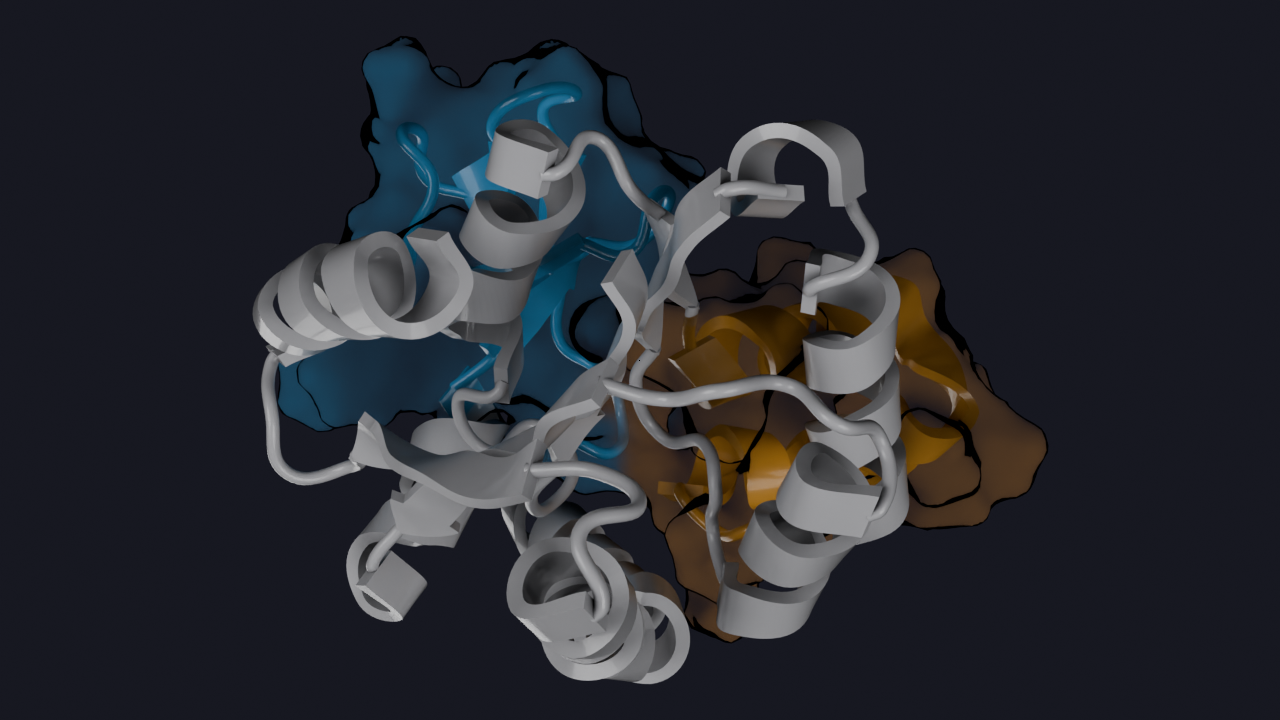
<figcaption>(a) Closed</figcaption>
</figure>
</div></td>
<td style="text-align: left;"><div
class="cell-output cell-output-display" width="50.0%"
data-layout-align="left">
<figure id="fig-open-closed-2">
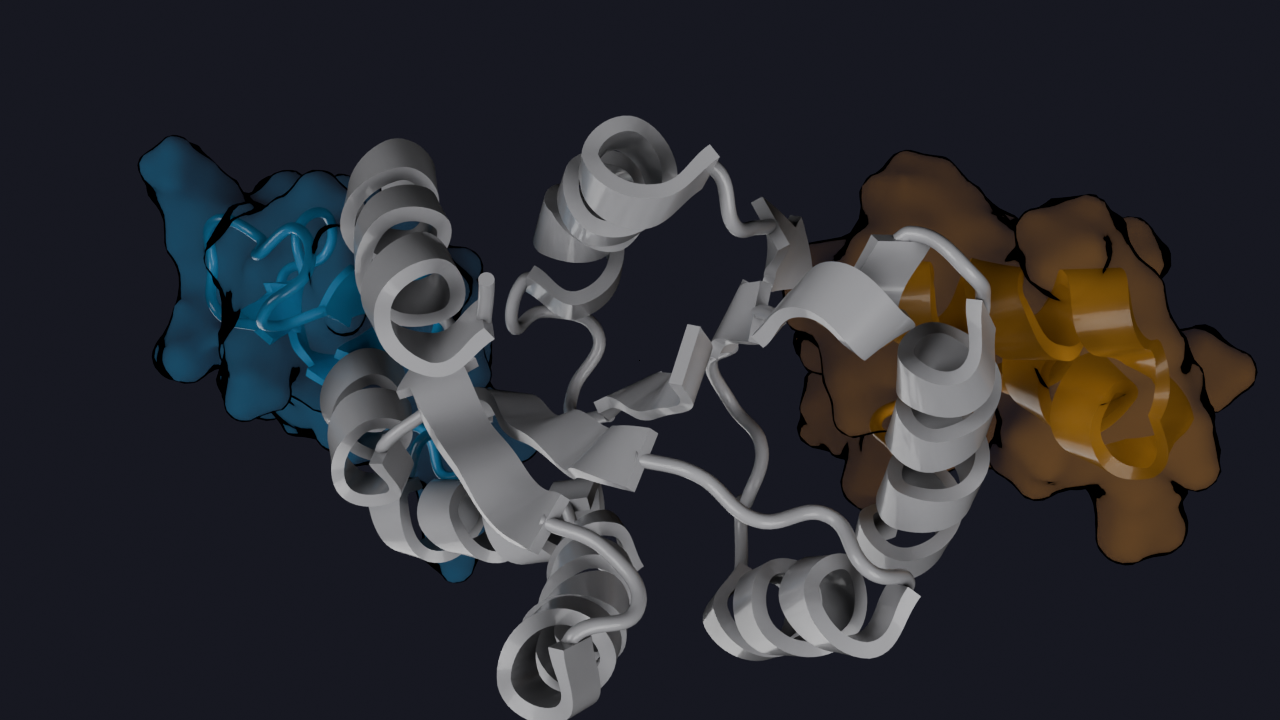
<figcaption>(b) Open</figcaption>
</figure>
</div></td>
</tr>
</tbody>
</table>

Figure 6: The most closed and most open conformations sampled in the
simulation, with a transparent surface over the LID and NMP domains.

## The contacts that hold the domains together

The simulation starts from the closed crystal structure and opens within
the first few nanoseconds, so the interesting part of the trajectory for
a movie is the very beginning. Before rendering it, we find what
actually ties the LID and NMP domains together in that closed starting
frame. A capped distance search between the heavy atoms of the two
domains returns every pair within 4.5 Å, and from the pairs we read off
the residues involved.

In [18]:
from MDAnalysis.analysis import contacts
from MDAnalysis.lib import distances

lid_heavy = u.select_atoms(f"({DOMAINS['LID']}) and not name H*")
nmp_heavy = u.select_atoms(f"({DOMAINS['NMP']}) and not name H*")

u.trajectory[0]
pairs, _ = distances.capped_distance(
    lid_heavy.positions, nmp_heavy.positions, max_cutoff=4.5
)
contact_lid = lid_heavy[np.unique(pairs[:, 0])].residues
contact_nmp = nmp_heavy[np.unique(pairs[:, 1])].residues

residue_pairs = {
    (f"{a.resname}{a.resid}", f"{b.resname}{b.resid}")
    for a, b in zip(lid_heavy[pairs[:, 0]], nmp_heavy[pairs[:, 1]])
}
for lid_res, nmp_res in sorted(residue_pairs):
    print(f"LID {lid_res}  <->  NMP {nmp_res}")

LID ARG156  <->  NMP ARG36
LID LYS157  <->  NMP ASP54

A salt bridge between Lys157 on the LID and Asp54 on the NMP domain,
flanked by two arginines, is the only direct contact between the two
domains. Following the User Guide’s [native contacts
example](https://userguide.mdanalysis.org/stable/examples/analysis/distances_and_contacts/contacts_native_fraction.html),
[`Contacts`](https://docs.mdanalysis.org/stable/documentation_pages/analysis/contacts.html#MDAnalysis.analysis.contacts.Contacts)
tracks the fraction of these starting contacts that survive in every
later frame.

In [19]:
q = contacts.Contacts(
    u, select=(lid_heavy, nmp_heavy), refgroup=(lid_heavy, nmp_heavy), radius=4.5
).run()

MOVIE_FRAMES = 120
time_ns = q.results.timeseries[:MOVIE_FRAMES, 0] * u.trajectory.dt / 1000
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(time_ns, q.results.timeseries[:MOVIE_FRAMES, 1], color="black", lw=1)
ax.set(xlabel="Time (ns)", ylabel="Fraction of contacts", ylim=(0, 1.05))
fig.tight_layout()

The residues go into one more selection string so that the animation can
draw them.

In [20]:
contact_resids = np.concatenate([contact_lid.resids, contact_nmp.resids])
CONTACTS = "resid " + " ".join(str(r) for r in contact_resids) + " and not name H*"
CONTACTS

'resid 156 157 36 54 and not name H*'

## An animation of the salt bridge breaking

The movie covers those first 60 frames (14 ns). The frames are 240 ps
apart, which is far too coarse to watch a side chain swing away, so we
lean on the playback controls of the
[`Molecule`](../api/reference/Molecule.html#molecularnodes.Molecule)
(see [Trajectories](trajectories.qmd)):

- `subframes` inserts extra scene frames between trajectory frames, and
  `interpolate` fills them by interpolating the positions, so four
  subframes stretch each trajectory frame over five scene frames.
- `average` averages a window of neighbouring frames, which takes the
  thermal jitter out of the motion so the slower domain opening reads
  clearly.

[`clear`](../api/reference/Canvas.html#molecularnodes.Canvas.clear)
removes the molecules from the scene while keeping the camera, lights
and render settings, and the aligned `Universe` is wrapped in a fresh
`Molecule`. The animation renders with EEVEE, which is many times faster
than Cycles and looks close enough for a movie.

In [21]:
canvas.clear()
canvas.engine = mn.scene.EEVEE()
canvas.fps = 24
canvas.resolution = (800, 600)

movie = mn.Molecule(u)
movie.dssp.init() # compute secondary structure for the movie
movie.subframes = 1
movie.interpolate = True
movie.average = 1

canvas.frame_range = (0, MOVIE_FRAMES * (movie.subframes + 1) - 1)
print(f"{canvas.frame_range[1] + 1} scene frames, "
      f"{(canvas.frame_range[1] + 1) / canvas.fps:.1f} s at {canvas.fps} fps")

Info: Deleted 3 data-block(s)
240 scene frames, 10.0 s at 24 fps

The node tree is built once, but Blender re-evaluates it on every frame.
A `Scene Time` node exposes the current frame, and a `Map Range` turns
it into a slow half turn over the length of the animation. After
centring the atoms on the CORE domain, a `Transform Geometry` node
applies that rotation, so the protein turns while the trajectory plays
underneath it. The transformed atoms then feed two branches: the
domain-coloured cartoon (secondary structure computed last, right before
the style, as before), and the contact residues drawn as ball-and-stick
in a highlight colour so they stand out as the salt bridge is pulled
apart.

In [22]:
with movie.tree.reset() as (atoms, join):
    turn = g.MapRange.float(g.SceneTime().o.frame, *canvas.frame_range, 0, np.pi)
    transformed = (
        color_domains(movie, atoms)
        >> mg.CentreOnSelection(selection=movie.selections.node(DOMAINS["CORE"]))
        >> g.TransformGeometry(rotation=g.CombineXYZ(y=turn + np.pi / 2))
    )

    transformed  >> mg.StyleCartoon(
        quality=4, material=glossy.material
    ) >> join

    (
        transformed
        >> mg.SetColor(
            color=(1.0, 0.85, 0.2, 1.0),
            selection=movie.selections.node(CONTACTS),
        )
        >> mg.StyleBallAndStick(
            selection=movie.selections.node(CONTACTS),
            sphere="Instance",
            quality=3,
            scale=0.3,
            material=glossy.material,
        )
        >> join
    )


movie.tree

[`animation`](../api/reference/Canvas.html#molecularnodes.Canvas.animation)
renders the scene’s frame range and returns the video for display. Pass
`path="adk.mp4"` to save it to disk as well. The camera is framed once,
with extra margin so the turning protein stays in shot.

In [23]:
canvas.frame = 0
canvas.look_at(movie, viewpoint="top", margin=0.35)
canvas.animation(path="adk.mp4")

## Where to go next

- Swap the dataset: `datasets.fetch_adk_transitions_DIMS()` holds 200
  short trajectories of AdK closing, which make a clean open-to-closed
  movie, and `datasets.fetch_membrane_peptide()` is a small peptide in a
  lipid bilayer.
- Compute something else and store it as an attribute — a distance, a
  hydrogen bond count, a PCA projection — and colour or scale the style
  by it as we did with the RMSF.
- The [Styles](styles.qmd), [Materials](materials.qmd) and [Node
  Trees](nodebpy.qmd) pages cover the full set of styles, colour nodes
  and materials used above, and [Rendering](rendering.qmd) covers
  frame-by-frame recording for animations where the camera or the style
  should change between frames.